In [5]:
def calculate_sma(data, window):
    return data['Close'].rolling(window=window).mean()

In [6]:
def is_sma_uptrend(sma):
    N = 20  # Check the last 20 points for uptrend
    y = sma[-N:]
    x = np.arange(len(y))
    slope = np.polyfit(x, y, 1)[0]
    return slope > 0

MSFT: 390.32606099446616
{'MSFT':            Open        High         Low       Close    Volume  Dividends  \
0    229.100472  230.584876  222.887571  225.364868  29743600        0.0   
1    223.762458  225.178057  220.311948  221.589920  30474000        0.0   
2    221.580089  223.998406  220.164506  221.924164  21903900        0.0   
3    216.124151  232.098758  215.416351  230.270279  42551800        0.0   
4    231.548259  233.219460  224.470281  224.686554  30198600        0.0   
..          ...         ...         ...         ...       ...        ...   
497  422.579987  422.820007  416.709991  417.130005  16582300        0.0   
498  417.630005  419.549988  414.290009  416.540009  13686400        0.0   
499  418.239990  419.750000  414.970001  416.059998  19169700        0.0   
500  416.000000  417.109985  409.000000  409.540009  20919800        0.0   
501  410.899994  415.660004  408.170013  414.709991  19115000        0.0   

     Stock Splits     SMA_200  
0             0.0    

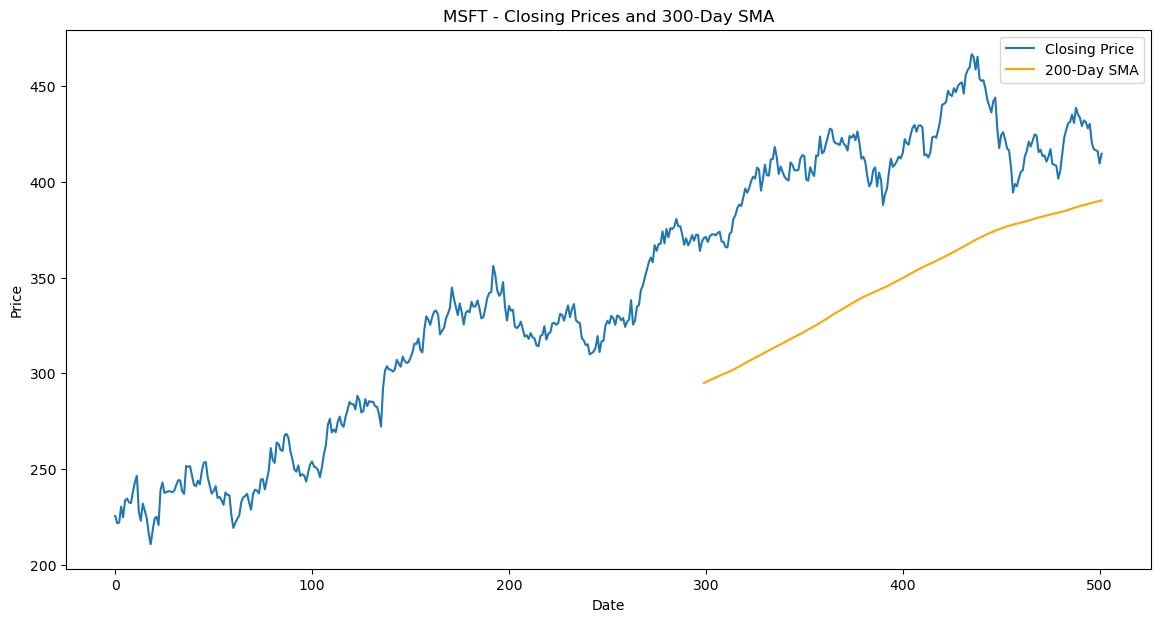

In [13]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ticker_uptrend = {}

ticker = "MSFT"
data = yf.Ticker(ticker).history("2y", interval="1d")
data.reset_index(drop=True, inplace=True)

data['SMA_200'] = calculate_sma(data, 300)
    
if not data['SMA_200'].dropna().empty:
    if is_sma_uptrend(data['SMA_200']):
        ticker_uptrend[ticker] = data

print(f"{ticker}: {data['SMA_200'].iloc[-1]}")
print(ticker_uptrend)

plt.figure(figsize=(14, 7))
plt.plot(data['Close'], label='Closing Price')
plt.plot(data['SMA_200'], label='200-Day SMA', color='orange')
plt.title(f'{ticker} - Closing Prices and 300-Day SMA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()